Before using the following notebook, mapping taxons.ipynb and sample_metadata.ipynb were both run. The following notebook contains the actual Micom code.

## Prepping kraken2 output for Micom:

In [16]:
import pandas as pd
import seaborn as sns
%matplotlib inline

genus_counts = pd.read_csv("G_counts.csv")

for col in ['class', 'order', 'family', 'genus']:
    genus_counts[col] = df[col].str.replace("^_", "", regex=True)

genus_counts["species"] = genus_counts["genus"] + " sp."

genus_counts["id"] = genus_counts["genus"] + "_" + genus_counts.groupby(['sample', 'genus']).cumcount().add(1).astype(str)

genus_counts = genus_counts.rename(columns={"sample": "sample_id", "reads": "abundance"})

micom_df = genus_counts[['id', 'genus', 'species', 'sample_id', 'abundance', 'class', 'order', 'family']]

micom_df.to_csv("micom_abundance_table.csv", index=False)


In [17]:
micom_df

,id,genus,species,sample_id,abundance,class,order,family
0,Prevotella_1,Prevotella,Prevotella sp.,SRR19524257,182452,Bacteroidia,Bacteroidales,Prevotellaceae
1,Xylanibacter_1,Xylanibacter,Xylanibacter sp.,SRR19524257,55638,Bacteroidia,Bacteroidales,Prevotellaceae
2,Segatella_1,Segatella,Segatella sp.,SRR19524257,20681,Bacteroidia,Bacteroidales,Prevotellaceae
3,Pseudoprevotella_1,Pseudoprevotella,Pseudoprevotella sp.,SRR19524257,2494,Bacteroidia,Bacteroidales,Prevotellaceae
4,Bacteroides_1,Bacteroides,Bacteroides sp.,SRR19524257,10804,Bacteroidia,Bacteroidales,Bacteroidaceae
...,...,...,...,...,...,...,...,...
2175,Cloacibacillus_1,Cloacibacillus,Cloacibacillus sp.,SRR19524270,64,Synergistia,Synergistales,Synergistaceae
2176,Fusobacterium_1,Fusobacterium,Fusobacterium sp.,SRR19524270,60,Fusobacteriia,Fusobacteriales,Fusobacteriaceae
2177,Methanobrevibacter_1,Methanobrevibacter,Methanobrevibacter sp.,SRR19524270,5739,Methanobacteria,Methanobacteriales,Methanobacteriaceae
2178,Methanosphaera_1,Methanosphaera,Methanosphaera sp.,SRR19524270,312,Methanobacteria,Methanobacteriales,Methanobacteriaceae


In [12]:
!pip install -q micom

print("Done! 🎉 ")

Done! 🎉 


In [13]:
from micom.data import test_data
test_data().head()

,id,genus,species,reactions,metabolites,sample_id,abundance
0,Escherichia_coli_1,Escherichia,Escherichia coli 0,95,72,sample_1,289
1,Escherichia_coli_2,Escherichia,Escherichia coli 1,95,72,sample_1,258
2,Escherichia_coli_3,Escherichia,Escherichia coli 2,95,72,sample_1,370
3,Escherichia_coli_4,Escherichia,Escherichia coli 3,95,72,sample_1,789
0,Escherichia_coli_1,Escherichia,Escherichia coli 0,95,72,sample_2,915


Pulling in Agora1 models:

In [15]:
!wget -O agora103_genus.qza https://zenodo.org/record/3755182/files/agora103_genus.qza?download=1

--2025-06-20 12:30:14--  https://zenodo.org/record/3755182/files/agora103_genus.qza?download=1
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.48.194, 188.185.43.25
connected. to zenodo.org (zenodo.org)|188.185.45.92|:443... 
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/3755182/files/agora103_genus.qza [following]
--2025-06-20 12:30:15--  https://zenodo.org/records/3755182/files/agora103_genus.qza
Reusing existing connection to zenodo.org:443.
200 OKequest sent, awaiting response... 
Length: 21080080 (20M) [application/octet-stream]
Saving to: ‘agora103_genus.qza’

agora103_genus.qza  100%[===================>]  20.10M  8.00MB/s    in 2.5s    

2025-06-20 12:30:18 (8.00 MB/s) - ‘agora103_genus.qza’ saved [21080080/21080080]



In [23]:
metadata = pd.read_csv("anderson_metadata.csv")
metadata

,Animal,Identification,Period,Diet,sample_id
0,Cow,1612,1,HPO,SRR19524268
1,Cow,1612,2,MAP,SRR19524256
2,Cow,1612,3,CTL,SRR19524252
3,Cow,1612,4,COS,SRR19524251
4,Cow,2046,1,MAP,SRR19524250
5,Cow,2046,2,COS,SRR19524249
6,Cow,2046,3,HPO,SRR19524248
7,Cow,2046,4,CTL,SRR19524246
8,Cow,2175,1,CTL,SRR19524245
9,Cow,2175,2,HPO,SRR19524270


In [25]:
tax = pd.merge(micom_df, metadata, on="sample_id")
tax

,id,genus,species,sample_id,abundance,class,order,family,Animal,Identification,Period,Diet
0,Prevotella_1,Prevotella,Prevotella sp.,SRR19524257,182452,Bacteroidia,Bacteroidales,Prevotellaceae,Goat,14201,1,COS
1,Xylanibacter_1,Xylanibacter,Xylanibacter sp.,SRR19524257,55638,Bacteroidia,Bacteroidales,Prevotellaceae,Goat,14201,1,COS
2,Segatella_1,Segatella,Segatella sp.,SRR19524257,20681,Bacteroidia,Bacteroidales,Prevotellaceae,Goat,14201,1,COS
3,Pseudoprevotella_1,Pseudoprevotella,Pseudoprevotella sp.,SRR19524257,2494,Bacteroidia,Bacteroidales,Prevotellaceae,Goat,14201,1,COS
4,Bacteroides_1,Bacteroides,Bacteroides sp.,SRR19524257,10804,Bacteroidia,Bacteroidales,Bacteroidaceae,Goat,14201,1,COS
...,...,...,...,...,...,...,...,...,...,...,...,...
2175,Cloacibacillus_1,Cloacibacillus,Cloacibacillus sp.,SRR19524270,64,Synergistia,Synergistales,Synergistaceae,Cow,2175,2,HPO
2176,Fusobacterium_1,Fusobacterium,Fusobacterium sp.,SRR19524270,60,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Cow,2175,2,HPO
2177,Methanobrevibacter_1,Methanobrevibacter,Methanobrevibacter sp.,SRR19524270,5739,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Cow,2175,2,HPO
2178,Methanosphaera_1,Methanosphaera,Methanosphaera sp.,SRR19524270,312,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Cow,2175,2,HPO


## Running MICOM to build models 
Current example is using agora2, after following the pipeline instructions for how to download as listed on the micom github[https://github.com/micom-dev/databases/blob/main/README.md])

In [41]:
from micom.workflows import build
from micom import Community
import pandas as pd

manifest_201 = build(tax, "/proj/gibbons/2025_methane_Andersen/workstation/databases/recipes/agora2/databases/agora201_refseq216_genus_1.qza", "agora2_models", solver="osqp", 
                 cutoff=0.001, threads=10)

Output()

[06/24/25 12:23:01] WARNING  Less than 50% of the abundance     ]8;id=918785;file:///users/jschoch/miniconda3/lib/python3.12/site-packages/micom/community.py\community.py]8;;\:]8;id=978154;file:///users/jschoch/miniconda3/lib/python3.12/site-packages/micom/community.py#229\229]8;;\
                             could be matched to the model                      
                             database. Model `SRR19524240` may                  
                             not be representative of the                       
                             sample                                             
[06/24/25 12:23:01] WARNING  Less than 50% of the abundance     ]8;id=195965;file:///users/jschoch/miniconda3/lib/python3.12/site-packages/micom/community.py\community.py]8;;\:]8;id=43192;file:///users/jschoch/miniconda3/lib/python3.12/site-packages/micom/community.py#229\229]8;;\
                             could be matched to the model                      
              

### Checking how well micom mapped:

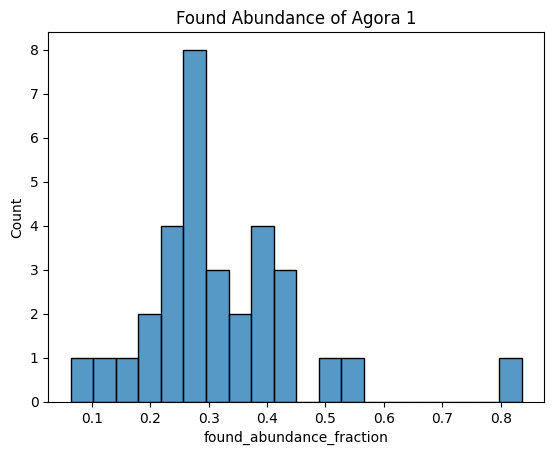

In [44]:
import matplotlib.pyplot as plt
ax = sns.histplot(manifest['found_abundance_fraction'], bins = 20, kde=False)
ax.set_title("Found Abundance of Agora 1")
plt.show()

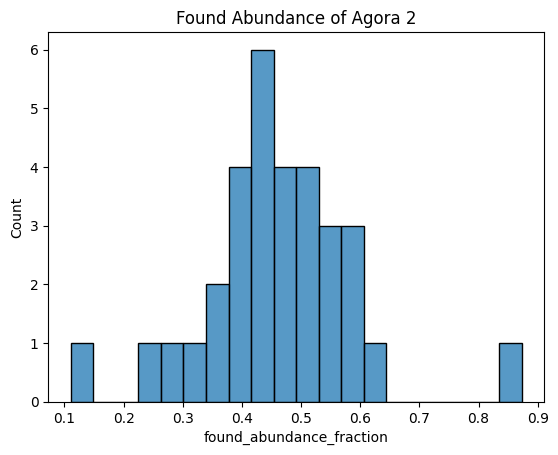

In [45]:
import matplotlib.pyplot as plt
ax = sns.histplot(manifest_201['found_abundance_fraction'], bins = 20, kde=False)
ax.set_title("Found Abundance of Agora 2")
plt.show()

Looking at results for just one diet:

In [62]:
manifest_201[manifest_201["Diet"] == "CTL"]

,sample_id,Animal,Identification,Period,Diet,file,found_taxa,total_taxa,found_fraction,found_abundance_fraction
5,SRR19524244,Cow,2179,2,CTL,SRR19524244.pickle,13.0,30.0,0.433333,0.431885
6,SRR19524245,Cow,2175,1,CTL,SRR19524245.pickle,18.0,39.0,0.461538,0.598505
7,SRR19524246,Cow,2046,4,CTL,SRR19524246.pickle,10.0,26.0,0.384615,0.289107
13,SRR19524252,Cow,1612,3,CTL,SRR19524252.pickle,12.0,28.0,0.428571,0.392551
16,SRR19524255,Goat,14201,2,CTL,SRR19524255.pickle,12.0,30.0,0.400000,0.607483
21,SRR19524260,Goat,14188,3,CTL,SRR19524260.pickle,11.0,28.0,0.392857,0.488636
27,SRR19524266,Goat,14100,1,CTL,SRR19524266.pickle,15.0,34.0,0.441176,0.457391
28,SRR19524267,Goat,13035,4,CTL,SRR19524267.pickle,15.0,33.0,0.454545,0.584831


## Growing models

In [81]:
from micom.workflows import grow, save_results
diets = {"CTL": "rumen_diets/rumen_diet_control_complete.csv", 
         "COS":"rumen_diets/rumen_diet_COS_complete.csv", 
         "MAP": "rumen_diets/rumen_diet_MAP_complete.csv", 
         "HPO": "rumen_diets/rumen_diet_HPO_complete.csv"}
for diet in diets.keys():
    medium = pd.read_csv(diets[diet])
    growth = grow(manifest_201[manifest_201["Diet"] == diet], "agora2_models", medium, tradeoff=0.8, threads=5)
    save_results(growth, f"growth_{diet}.zip")

Output()

Output()

Output()

Output()

## Looking at exchange results

In [179]:
from micom.workflows import load_results
overall_exchange = None
diets = ["CTL", "COS", "MAP", "HPO"]

for diet in diets:
    growth = load_results(f"growth_{diet}.zip")
    growth_exchanges=pd.merge(growth.exchanges,metadata,on='sample_id')
    if overall_exchange is not None:
        overall_exchange = pd.concat([overall_exchange, growth_exchanges],ignore_index=True)
    else:
        overall_exchange = growth_exchanges
        
overall_exchange

In [197]:
flux_summary = (
    overall_exchange.pivot_table(
        index=['sample_id', 'metabolite'],
        columns='direction',
        values='flux',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

flux_summary['net_flux'] = flux_summary.get('export', 0) + flux_summary.get('import', 0) # since imports all neg
flux_summary

direction,sample_id,metabolite,export,import,net_flux
0,SRR19524239,12dhchol[e],100.000000,-6.871036,93.128964
1,SRR19524239,15dap[e],18.219249,-100.000000,-81.780751
2,SRR19524239,26dap_M[e],11.576591,-500.001149,-488.424558
3,SRR19524239,2ddglcn[e],172.033898,-200.000000,-27.966102
4,SRR19524239,2dmmq8[e],0.000000,-0.000153,-0.000153
...,...,...,...,...,...
6297,SRR19524270,uri[e],309.114114,-169.602022,139.512092
6298,SRR19524270,val_L[e],1108.820283,-311.105601,797.714682
6299,SRR19524270,xan[e],615.774656,-136.975116,478.799540
6300,SRR19524270,zn2[e],0.000000,-0.000719,-0.000719


In [195]:
netflux = pd.merge(flux_summary, metadata, on="sample_id", how = "left")
netflux

,sample_id,metabolite,export,import,net_flux,Animal,Identification,Period,Diet
0,SRR19524239,12dhchol[e],100.000000,-6.871036,93.128964,Goat,13035,3,HPO
1,SRR19524239,15dap[e],18.219249,-100.000000,-81.780751,Goat,13035,3,HPO
2,SRR19524239,26dap_M[e],11.576591,-500.001149,-488.424558,Goat,13035,3,HPO
3,SRR19524239,2ddglcn[e],172.033898,-200.000000,-27.966102,Goat,13035,3,HPO
4,SRR19524239,2dmmq8[e],0.000000,-0.000153,-0.000153,Goat,13035,3,HPO
...,...,...,...,...,...,...,...,...,...
6297,SRR19524270,uri[e],309.114114,-169.602022,139.512092,Cow,2175,2,HPO
6298,SRR19524270,val_L[e],1108.820283,-311.105601,797.714682,Cow,2175,2,HPO
6299,SRR19524270,xan[e],615.774656,-136.975116,478.799540,Cow,2175,2,HPO
6300,SRR19524270,zn2[e],0.000000,-0.000719,-0.000719,Cow,2175,2,HPO


Looking at just methane:

In [219]:
netflux[netflux["metabolite"]=="ch4[e]"]

,sample_id,metabolite,export,import,net_flux,Animal,Identification,Period,Diet
425,SRR19524241,ch4[e],100.000000,0.0,100.000000,Goat,13035,1,MAP
856,SRR19524243,ch4[e],33.333333,0.0,33.333333,Cow,2179,3,MAP
1074,SRR19524244,ch4[e],100.000000,0.0,100.000000,Cow,2179,2,CTL
1275,SRR19524245,ch4[e],100.000000,0.0,100.000000,Cow,2175,1,CTL
1488,SRR19524246,ch4[e],100.000000,0.0,100.000000,Cow,2046,4,CTL
1668,SRR19524247,ch4[e],100.000000,0.0,100.000000,Cow,2179,1,COS
1849,SRR19524248,ch4[e],100.000000,0.0,100.000000,Cow,2046,3,HPO
2252,SRR19524250,ch4[e],99.999386,0.0,99.999386,Cow,2046,1,MAP
2461,SRR19524251,ch4[e],100.000000,0.0,100.000000,Cow,1612,4,COS
2648,SRR19524252,ch4[e],74.998436,0.0,74.998436,Cow,1612,3,CTL


Recorded fermentation products from the experimental data:

In [116]:
exp_data = pd.read_csv("table_s2_fermentation_products.csv")
exp_data['Animal number'] = exp_data['Animal number'].astype(str).str.replace(r'^201', '', regex=True)
exp_data

,Animal number,Species,Period,Diet,Metaproteomics sample number,Acetate mmol/l,propionate mmol/l,butyrate mmol/l,iso butyrate mmol/l,iso valerate mmol/l,...,Acetate %/sum,propionate %/sum,iso butyrate %/sum,butyrate %/sum,iso valerate %/sum,valerate %/sum,caproate %/sum,NH3 mmol/l,CH4 g/d,CH4 g /kg DMI
0,1612,Cow,P1,HPO,1,82.78,15.68,11.46,0.93,1.13,...,73.29,13.88,0.82,10.15,1.00,0.63,0.22,3.76,367.616,20.674
1,1612,Cow,P2,MAP,2,36.63,7.16,4.20,0.39,0.46,...,74.39,14.54,0.78,8.52,0.93,0.65,0.17,3.36,421.499,21.065
2,1612,Cow,P3,CTL,3,44.72,8.57,6.60,0.42,0.54,...,72.89,13.97,0.69,10.76,0.88,0.61,0.20,3.81,389.170,20.763
3,1612,Cow,P4,COS,4,31.16,8.29,2.61,0.38,0.39,...,72.03,19.15,0.87,6.03,0.91,0.81,0.20,2.10,279.669,18.082
4,2046,Cow,P1,MAP,5,77.81,15.08,11.73,1.09,1.47,...,71.90,13.93,1.01,10.84,1.36,0.74,0.21,6.48,311.943,15.325
5,2046,Cow,P2,COS,6,33.53,10.90,2.66,0.47,0.80,...,68.61,22.31,0.97,5.45,1.63,0.97,0.06,0.31,199.526,11.016
6,2046,Cow,P3,HPO,7,42.97,9.87,6.30,0.49,0.58,...,70.71,16.24,0.81,10.37,0.96,0.72,0.18,4.38,288.252,15.084
7,2046,Cow,P4,CTL,8,46.17,10.57,6.87,0.44,0.53,...,70.76,16.19,0.67,10.53,0.81,0.85,0.19,2.95,325.535,16.877
8,2175,Cow,P1,CTL,9,48.70,7.90,8.05,0.64,1.01,...,72.52,11.75,0.95,11.99,1.51,0.84,0.45,7.00,388.952,21.764
9,2175,Cow,P2,HPO,10,35.71,6.61,4.21,0.41,0.53,...,74.53,13.79,0.85,8.79,1.10,0.68,0.25,6.56,320.534,16.204
